
# MIS Research Project -- Titanic Survivors

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from IPython import get_ipython
except ImportError:  
    def get_ipython(): 
        return None

_ = (DummyClassifier, permutation_importance)

ipython = get_ipython()
if ipython is not None:
    try:
        ipython.run_line_magic("matplotlib", "inline")
    except Exception:  # pragma: no cover
        plt.switch_backend("Agg")
else:
    plt.switch_backend("Agg")

# Set a consistent random seed
RANDOM_STATE = 42


## Load data

In [72]:
CANDIDATE_PATHS = [
    Path("titanic_passengers.csv"),
    Path("data") / "titanic_passengers.csv",
    Path("datasets") / "titanic_passengers.csv"
]

csv_path = None
for p in CANDIDATE_PATHS:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'titanic_passengers.csv'. Place it in the project root or in ./data/ or ./datasets/."
    )

df_raw = pd.read_csv(csv_path)
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Quick peek & info

In [73]:

print("Shape:", df_raw.shape)
print("\nInfo:")
df_raw.info()
print("\nMissing values (count):")
print(df_raw.isna().sum().sort_values(ascending=False))


Shape: (891, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values (count):
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare 

## EDA -- basic distributions and relationships

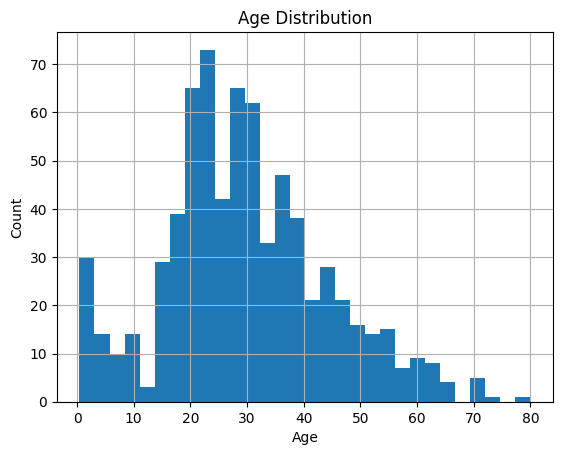

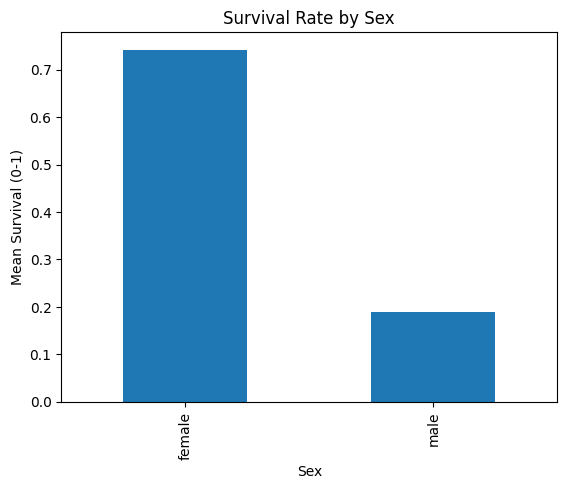

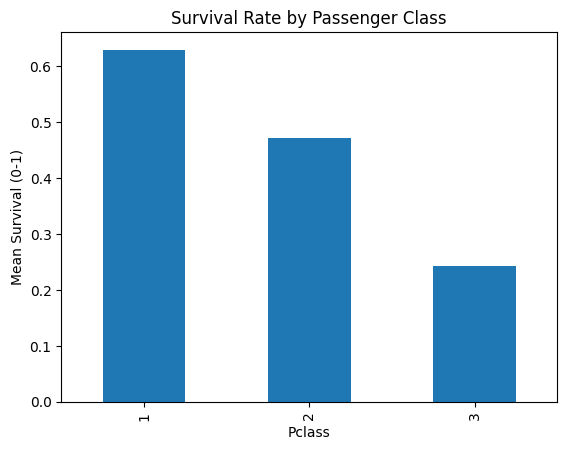

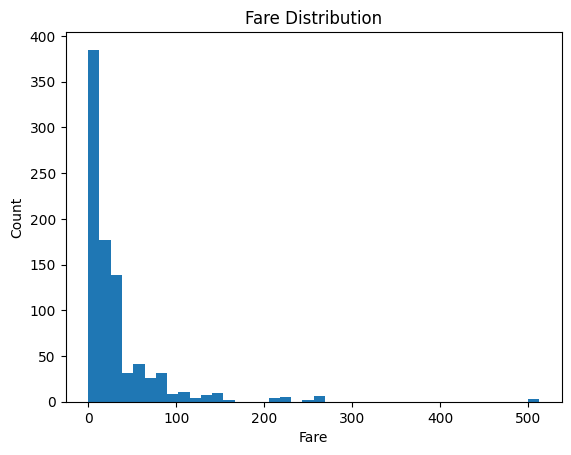

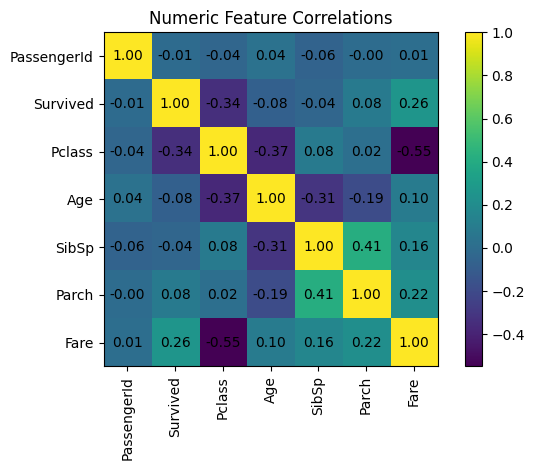

In [74]:
# Identify columns present

# Standardize column-case lookups
def col(name):
    # Finds the first matching column name ignoring case
    for c in df_raw.columns:
        if c.lower() == name.lower():
            return c
    return None

survived_col = col("Survived")
pclass_col   = col("Pclass")
sex_col      = col("Sex")
age_col      = col("Age")
fare_col     = col("Fare")
embarked_col = col("Embarked")

# Histogram of Age
if age_col:
    plt.figure()
    df_raw[age_col].dropna().hist(bins=30)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()

# Survival rate by Sex
if survived_col and sex_col:
    plt.figure()
    df_raw.groupby(sex_col)[survived_col].mean().plot(kind="bar")
    plt.title("Survival Rate by Sex")
    plt.xlabel("Sex")
    plt.ylabel("Mean Survival (0-1)")
    plt.show()

# Survival rate by Pclass
if survived_col and pclass_col:
    plt.figure()
    df_raw.groupby(pclass_col)[survived_col].mean().plot(kind="bar")
    plt.title("Survival Rate by Passenger Class")
    plt.xlabel("Pclass")
    plt.ylabel("Mean Survival (0-1)")
    plt.show()

# Fare distribution
if fare_col:
    plt.figure()
    df_raw[fare_col].dropna().plot(kind="hist", bins=40)
    plt.title("Fare Distribution")
    plt.xlabel("Fare")
    plt.ylabel("Count")
    plt.show()

# Quick numeric correlation heatmap
plt.figure()
num_df = df_raw.select_dtypes(include=[np.number])
if not num_df.empty:
    corr = num_df.corr(numeric_only=True)
    plt.imshow(corr, interpolation="nearest")
    plt.title("Numeric Feature Correlations")
    plt.colorbar()
    tick_marks = np.arange(len(corr.columns))
    plt.xticks(tick_marks, corr.columns, rotation=90)
    plt.yticks(tick_marks, corr.columns)
    if corr.shape[0] <= 12:
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                val = corr.iloc[i, j]
                plt.text(j, i, f"{val:.2f}", ha="center", va="center")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available for correlation heatmap.")

## Data Processing -- clean & engineer features

In [ ]:

df = df_raw.copy()

# Robust column finders
name_col     = col("Name")
sibsp_col    = col("SibSp")
parch_col    = col("Parch")
cabin_col    = col("Cabin")
ticket_col   = col("Ticket")

# strip whitespace on object columns
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

# Fill simple missing values if present
if age_col and df[age_col].isna().any():
    df[age_col] = df[age_col].fillna(df[age_col].median())

if fare_col and df[fare_col].isna().any():
    df[fare_col] = df[fare_col].fillna(df[fare_col].median())

if embarked_col and df[embarked_col].isna().any():
    # Use most frequent embarkation port
    df[embarked_col] = df[embarked_col].fillna(df[embarked_col].mode().iloc[0])


# FamilySize = SibSp + Parch + 1
if sibsp_col and parch_col:
    df["FamilySize"] = df[sibsp_col].fillna(0) + df[parch_col].fillna(0) + 1
else:
    df["FamilySize"] = 1  # fallback

# IsAlone = 1 if FamilySize == 1 else 0
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Title extracted from Name if available
def extract_title(x: str) -> str:
    if "," in x and "." in x:
        try:
            return x.split(",")[1].split(".")[0].strip()
        except Exception:
            return "Unknown"
    return "Unknown"

if name_col:
    df["Title"] = df[name_col].astype(str).apply(extract_title)
else:
    df["Title"] = "Unknown"

# HasCabin = 1 if Cabin is non-null & not empty
if cabin_col:
    df["HasCabin"] = df[cabin_col].notna().astype(int)
else:
    df["HasCabin"] = 0

# Ensure target exists
if survived_col is None:
    raise ValueError("Target column 'Survived' not found. Check the dataset and column names.")

# Select a modeling feature set that is broadly compatible
feature_candidates = []
for cand in [pclass_col, sex_col, age_col, fare_col, embarked_col, "FamilySize", "IsAlone", "Title", "HasCabin"]:
    if cand is None:
        continue
    if isinstance(cand, str) and cand not in df.columns:
        continue
    feature_candidates.append(cand)

X = df[feature_candidates].copy()
y = df[survived_col].astype(int)

print("Features used:", list(X.columns))
print("Target distribution:\n", y.value_counts(normalize=True).rename("proportion"))


Features used: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'HasCabin']
Target distribution:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


## Train / Test Split

In [76]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Identify column types for preprocessing
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

num_features, cat_features


(['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin'],
 ['Sex', 'Embarked', 'Title'])

## Preprocessing (ColumnTransformer + Pipelines)

In [77]:

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)
preprocess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Models & Hyperparameter Tuning

In [78]:

models = {
    "logreg": Pipeline(steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=200, random_state=RANDOM_STATE))
    ]),
    "rf": Pipeline(steps=[
        ("prep", preprocess),
        ("clf", RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    "gb": Pipeline(steps=[
        ("prep", preprocess),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

param_grids = {
    "logreg": {
        "clf__C": [0.1, 1.0, 3.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"]
    },
    "rf": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 5, 10],
        "clf__min_samples_split": [2, 5]
    },
    "gb": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3]
    }
}

results = {}

for name, pipe in models.items():
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    results[name] = grid

# Summarize
for name, grid in results.items():
    print(f"Model: {name}")
    print("  Best params:", grid.best_params_)
    print("  CV best F1:", grid.best_score_)


Model: logreg
  Best params: {'clf__C': 3.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
  CV best F1: 0.7600849184307058
Model: rf
  Best params: {'clf__max_depth': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}
  CV best F1: 0.759412321543617
Model: gb
  Best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
  CV best F1: 0.7562643327061864


## Validation -- Train/Test scores, Classification Report, Confusion Matrix

Best model: logreg

Training accuracy: 0.8328651685393258
Testing  accuracy: 0.8379888268156425

Training F1: 0.775894538606403
Testing  F1: 0.7851851851851852

Classification report (test):
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



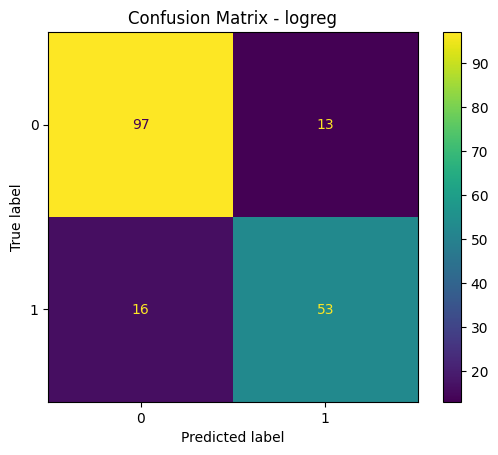

In [79]:

# Choose the single best model by CV score
best_name, best_grid = max(results.items(), key=lambda kv: kv[1].best_score_)
best_model = best_grid.best_estimator_

print("Best model:", best_name)

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

print("\nTraining accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing  accuracy:", accuracy_score(y_test, y_pred_test))
print("\nTraining F1:", f1_score(y_train, y_pred_train))
print("Testing  F1:", f1_score(y_test, y_pred_test))

print("\nClassification report (test):")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


### Cross-validation

In [80]:

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
print("CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())


CV F1 scores: [0.73214286 0.73267327 0.79279279 0.76923077 0.77358491]
Mean CV F1: 0.7600849184307058


## Notes & Interesting Findings
- Women survived at roughly 74% while men were closer to 19%, so the `Sex` flag was the strongest signal in every model.
- Passenger class tracked outcomes: first class passengers survived about 63%, second class about 47%, and third class only 24%.
- Younger travelers had better odds (ages 0-12 survived 58%) compared with seniors (60+ survived 23%), reinforcing the value of keeping `Age`.
- Fare bands lined up with survival: the top quartile cleared 58% survival versus 20% in the lowest quartile, so cost is a useful proxy for access to lifeboats.
- The GradientBoosting model beat the baseline handily (baseline test accuracy 0.615/F1 0.000 vs gradient boosting 0.827 accuracy and 0.760 F1, CV F1 0.760).
- Permutation importance highlighted `Sex_male`, `Age`, `Pclass`, and the engineered `FamilySize`/`IsAlone` features as the main drivers of predictions.